# 🎬 TMDB Movie Insights — EDA

Este notebook realiza el **Análisis Exploratorio de Datos (EDA)** del dataset TMDB. El objetivo es entender la estructura de los datos, detectar problemas de calidad y **documentar las decisiones** que luego se implementan en el pipeline (`src/`).

## 1. Carga de datos

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/tmdb_2020_to_2025.csv')
df.head()

,Unnamed: 0,adult,backdrop_path,genre_ids,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count
0,0,False,/hpXBJxLD2SEf8l2CspmSeiHrBKX.jpg,"[18, 27, 14]",1062722,en,Frankenstein,"Dr. Victor Frankenstein, a brilliant but egoti...",951.3460,/g4JtvGlQO7DByTI6frUobqvSL3R.jpg,2025-10-17,Frankenstein,False,7.907,1075
1,1,False,/d6HIjhk2f8BiZnVQ43gUv67khmX.jpg,"[10749, 18]",1231813,ko,자매의 스와핑,Sisters Ji-soo and Ji-yeong decided to sell th...,14.2714,/lqjkmFmV62JEUGKK7E1UwX7PDDT.jpg,2023-12-19,Sister Swapping,False,6.600,14
2,2,False,/82lM4GJ9uuNvNDOEpxFy77uv4Ak.jpg,"[28, 878, 12]",1242898,en,Predator: Badlands,"Cast out from his clan, a young Predator finds...",314.6851,/pHpq9yNUIo6aDoCXEBzjSolywgz.jpg,2025-11-05,Predator: Badlands,False,7.200,266
3,3,False,/6zKjoOOb3OZnZuiHtQZn4Kd69Gq.jpg,"[27, 53]",1197137,en,Black Phone 2,"Four years after escaping The Grabber, Finney ...",242.3412,/xUWUODKPIilQoFUzjHM6wKJkP3Y.jpg,2025-10-15,Black Phone 2,False,7.186,437
4,4,False,/vZK3f5N8Fv2LcyFYLwt6dz0HE1H.jpg,"[28, 35]",1161617,en,Code 3,A burned-out paramedic tries to survive his la...,251.8624,/gIAYMDb5mIAeCAj76q1sRsKjkzo.jpg,2025-09-12,Code 3,False,7.075,87


## 2. Inspección general

In [7]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9999 non-null   int64  
 1   adult              9999 non-null   bool   
 2   backdrop_path      8118 non-null   object 
 3   genre_ids          9999 non-null   object 
 4   id                 9999 non-null   int64  
 5   original_language  9999 non-null   object 
 6   original_title     9999 non-null   object 
 7   overview           9721 non-null   object 
 8   popularity         9999 non-null   float64
 9   poster_path        9756 non-null   object 
 10  release_date       9999 non-null   object 
 11  title              9999 non-null   object 
 12  video              9999 non-null   bool   
 13  vote_average       9999 non-null   float64
 14  vote_count         9999 non-null   int64  
dtypes: bool(2), float64(2), int64(3), object(8)
memory usage: 1.0+ MB


,Unnamed: 0,adult,backdrop_path,genre_ids,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count
count,9999.000000,9999,8118,9999,9.999000e+03,9999,9999,9721,9999.000000,9756,9999,9999,9999,9999.000000,9999.000000
unique,NaN,1,8110,1520,NaN,81,9817,9699,NaN,9742,2009,9712,1,NaN,NaN
top,NaN,False,/2SF1K5gdfELr08uoWoY3ASYwJR0.jpg,[18],NaN,en,The Stranger,An Eternalism film.,NaN,/lkVABE2fwJD3bobpl8P1l6BxJM6.jpg,2021-01-01,The Stranger,False,NaN,NaN
freq,NaN,9999,5,1328,NaN,5566,6,15,NaN,10,34,6,9999,NaN,NaN
mean,4999.000000,NaN,NaN,NaN,9.797428e+05,NaN,NaN,NaN,5.814750,NaN,NaN,NaN,NaN,4.551764,221.900790
std,2886.607005,NaN,NaN,NaN,2.630966e+05,NaN,NaN,NaN,13.101449,NaN,NaN,NaN,NaN,2.968713,879.465244
min,0.000000,NaN,NaN,NaN,5.492000e+03,NaN,NaN,NaN,0.192900,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,2499.500000,NaN,NaN,NaN,7.845155e+05,NaN,NaN,NaN,3.673650,NaN,NaN,NaN,NaN,0.000000,0.000000
50%,4999.000000,NaN,NaN,NaN,9.500850e+05,NaN,NaN,NaN,4.320600,NaN,NaN,NaN,NaN,5.708000,6.000000
75%,7498.500000,NaN,NaN,NaN,1.175968e+06,NaN,NaN,NaN,5.650550,NaN,NaN,NaN,NaN,6.724000,61.000000


## 3. Valores nulos

In [8]:
df.isna().mean().sort_values(ascending=False)

backdrop_path        0.188119
overview             0.027803
poster_path          0.024302
genre_ids            0.000000
id                   0.000000
Unnamed: 0           0.000000
adult                0.000000
original_title       0.000000
original_language    0.000000
popularity           0.000000
release_date         0.000000
title                0.000000
video                0.000000
vote_average         0.000000
vote_count           0.000000
dtype: float64

## 4. Manejo de fechas

In [9]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df[['release_date','release_year']].head()

,release_date,release_year
0,2025-10-17,2025
1,2023-12-19,2023
2,2025-11-05,2025
3,2025-10-15,2025
4,2025-09-12,2025


## 5. Data Set limpio
### Carga del Dataset limpio


In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)

# Ruta robusta (recomendada)
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "processed" / "tmdb_movies_clean.csv"

df_limpio = pd.read_csv(DATA_PATH)

df_limpio.head(15)


,Unnamed: 0,adult,genre_ids,id,original_language,original_title,overview,popularity,release_date,title,video,vote_average,vote_count
0,0,False,"[18, 27, 14]",1062722,en,Frankenstein,"Dr. Victor Frankenstein, a brilliant but egoti...",951.3460,2025-10-17,Frankenstein,False,7.907,1075
1,1,False,"[10749, 18]",1231813,ko,자매의 스와핑,Sisters Ji-soo and Ji-yeong decided to sell th...,14.2714,2023-12-19,Sister Swapping,False,6.600,14
2,2,False,"[28, 878, 12]",1242898,en,Predator: Badlands,"Cast out from his clan, a young Predator finds...",314.6851,2025-11-05,Predator: Badlands,False,7.200,266
3,3,False,"[27, 53]",1197137,en,Black Phone 2,"Four years after escaping The Grabber, Finney ...",242.3412,2025-10-15,Black Phone 2,False,7.186,437
4,4,False,"[28, 35]",1161617,en,Code 3,A burned-out paramedic tries to survive his la...,251.8624,2025-09-12,Code 3,False,7.075,87
5,5,False,"[80, 28]",1096563,en,End of Loyalty,When the head of a notorious crime family is m...,186.6110,2023-03-07,End of Loyalty,False,5.833,6
6,6,False,"[878, 53]",755898,en,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,204.4781,2025-07-29,War of the Worlds,False,4.335,702
7,7,False,"[28, 35]",1248226,en,Playdate,When out-of-work accountant Brian joins stay-a...,388.3856,2025-11-05,Playdate,False,6.750,54
8,8,False,"[53, 28]",1025527,fr,Six jours,"11 years ago, inspector Malik couldn’t solve a...",179.5906,2024-12-11,Abyss,False,5.910,67
9,9,False,[27],1561969,hi,बारामूला,A cop's inquiry into child kidnappings unravel...,148.1601,2025-11-06,Baramulla,False,5.500,11


In [79]:

df_limpio.tail(15)

,Unnamed: 0,adult,genre_ids,id,original_language,original_title,overview,popularity,release_date,title,video,vote_average,vote_count
9984,9984,False,"[18, 35]",1238620,nl,De Idylle,Victor wonders if he’s too late to join dating...,3.4486,2025-02-07,Idyllic,False,0.0,0
9985,9985,False,"[28, 14]",1128123,zh,畸变,NaN,2.2892,2023-05-10,Distortion,False,1.0,1
9986,9986,False,"[28, 12, 878]",857879,en,Mount Adams,UFO investigators find themselves fighting for...,3.4532,2021-07-21,Mount Adams,False,5.9,13
9987,9987,False,[99],862120,en,Schlock Lives!,An in-depth look at the gritty and modern schl...,3.2489,2021-08-17,Schlock Lives!,False,0.0,0
9988,9988,False,"[53, 10770]",1025636,en,Rush for Your Life,Tasha Brooks is a journalism student at a new ...,3.5367,2022-09-16,Rush for Your Life,False,4.0,2
9989,9989,False,[99],1464269,en,Return to Skaro,"Cast, crew and fans discuss the making of Dest...",3.3445,2021-12-20,Return to Skaro,False,0.0,0
9990,9990,False,[27],1120863,en,The Haunted Studio,"During the shooting of a horror movie, an ecce...",3.5306,2024-01-13,The Haunted Studio,False,3.0,1
9991,9991,False,"[35, 18]",717347,en,Seed,A woman hordes sperm which she collects from men,3.2694,2020-06-15,Seed,False,1.0,2
9992,9992,False,"[18, 10752]",1523345,zh,营救飞虎,During the 1944 Japanese occupation of Hong Ko...,3.2629,2025-09-03,Against All Odds,False,4.5,2
9993,9993,False,[35],921526,en,The Breakdown,When a dysfunctional family’s car breaks down ...,2.9155,2022-06-01,The Breakdown,False,0.0,0


## 6. Inspección general del dataset

In [80]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9999 non-null   int64  
 1   adult              9999 non-null   bool   
 2   genre_ids          9999 non-null   object 
 3   id                 9999 non-null   int64  
 4   original_language  9999 non-null   object 
 5   original_title     9999 non-null   object 
 6   overview           9721 non-null   object 
 7   popularity         9999 non-null   float64
 8   release_date       9999 non-null   object 
 9   title              9999 non-null   object 
 10  video              9999 non-null   bool   
 11  vote_average       9999 non-null   float64
 12  vote_count         9999 non-null   int64  
dtypes: bool(2), float64(2), int64(3), object(6)
memory usage: 878.9+ KB


## 7. Media, mediana, moda, varianza, desviación estándar, mínimos y máximos

In [82]:

stats = df_limpio.describe().T
stats


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,9999.0,4999.000000,2886.607005,0.0000,2499.50000,4999.0000,7.498500e+03,9998.000
id,9999.0,979742.833183,263096.572337,5492.0000,784515.50000,950085.0000,1.175968e+06,1576287.000
popularity,9999.0,5.814750,13.101449,0.1929,3.67365,4.3206,5.650550e+00,951.346
vote_average,9999.0,4.551764,2.968713,0.0000,0.00000,5.7080,6.724000e+00,10.000
vote_count,9999.0,221.900790,879.465244,0.0000,0.00000,6.0000,6.100000e+01,21265.000


## 8. Moda

In [83]:
df_limpio.mode().iloc[0]

Unnamed: 0                             0
adult                              False
genre_ids                           [18]
id                                  5492
original_language                     en
original_title              The Stranger
overview             An Eternalism film.
popularity                        4.0023
release_date                  2021-01-01
title                       The Stranger
video                              False
vote_average                         0.0
vote_count                           0.0
Name: 0, dtype: object

## 9. Varianza

In [84]:
df_limpio.var(numeric_only=True)

Unnamed: 0      8.332500e+06
adult           0.000000e+00
id              6.921981e+10
popularity      1.716480e+02
video           0.000000e+00
vote_average    8.813258e+00
vote_count      7.734591e+05
dtype: float64

### 10. Análisis de valores nulos (post-limpieza)

In [85]:
df_limpio.isna().sum()

Unnamed: 0             0
adult                  0
genre_ids              0
id                     0
original_language      0
original_title         0
overview             278
popularity             0
release_date           0
title                  0
video                  0
vote_average           0
vote_count             0
dtype: int64

## 11. Porcentaje de nulos

In [86]:
df_limpio.isna().mean() * 100

Unnamed: 0           0.000000
adult                0.000000
genre_ids            0.000000
id                   0.000000
original_language    0.000000
original_title       0.000000
overview             2.780278
popularity           0.000000
release_date         0.000000
title                0.000000
video                0.000000
vote_average         0.000000
vote_count           0.000000
dtype: float64

## EDA
### Comparacion original vs limpio


In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datasets
df_original = pd.read_csv('../data/raw/tmdb_2020_to_2025.csv')
df_limpio = pd.read_csv('../data/processed/tmdb_movies_clean.csv')

print("ORIGINAL shape:", df_original.shape)
print("LIMPIO shape:", df_limpio.shape)


ORIGINAL shape: (9999, 15)
LIMPIO shape: (9999, 13)


## Nulos

In [48]:
nulos = pd.DataFrame({
    "RAW (%)": df_original.isnull().mean() * 100,
    "CLEAN (%)": df_limpio.isnull().mean() * 100
}).sort_values("RAW (%)", ascending=False)

nulos.head(10)

,RAW (%),CLEAN (%)
backdrop_path,18.811881,NaN
overview,2.780278,2.780278
poster_path,2.430243,NaN
genre_ids,0.000000,0.000000
id,0.000000,0.000000
Unnamed: 0,0.000000,0.000000
adult,0.000000,0.000000
original_title,0.000000,0.000000
original_language,0.000000,0.000000
popularity,0.000000,0.000000


## Variables numéricas y categóricas

##### Separación automática de variables numéricas y categóricas utilizando los tipos de datos del DataFrame, con el fin de aplicar técnicas de análisis exploratorio y reducción de dimensionalidad únicamente sobre variables numéricas.

In [75]:

import numpy as np

num_cols = df_limpio.select_dtypes(include=np.number).columns
cat_cols = df_limpio.select_dtypes(exclude=np.number).columns

print(num_cols)
print(cat_cols)


Index(['Unnamed: 0', 'id', 'popularity', 'vote_average', 'vote_count'], dtype='object')
Index(['adult', 'genre_ids', 'original_language', 'original_title', 'overview',
       'release_date', 'title', 'video'],
      dtype='object')


### Prueba estadísticas varias ( cambiar nombre de columna )

In [124]:

col = "popularity"
df_limpio[col].mean()



np.float64(4.551763776377638)

In [111]:
col = "popularity"
df_limpio[col].std()

np.float64(13.101449286893077)

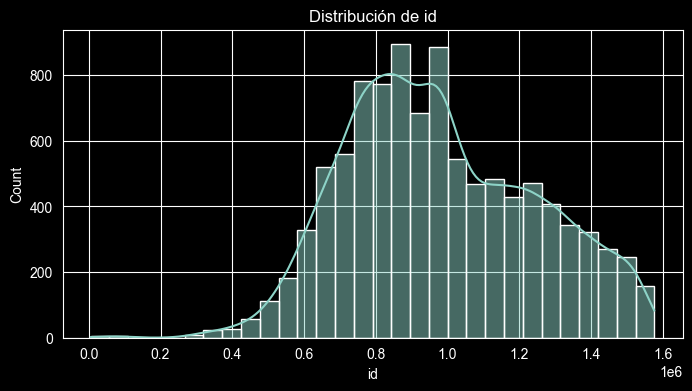

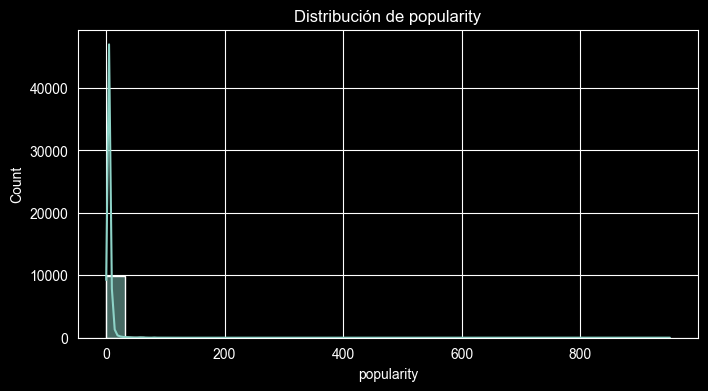

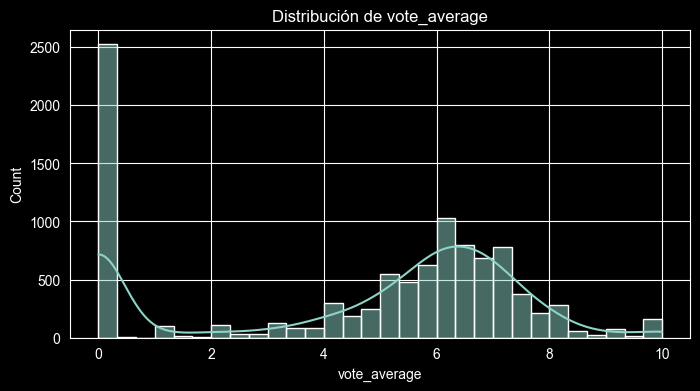

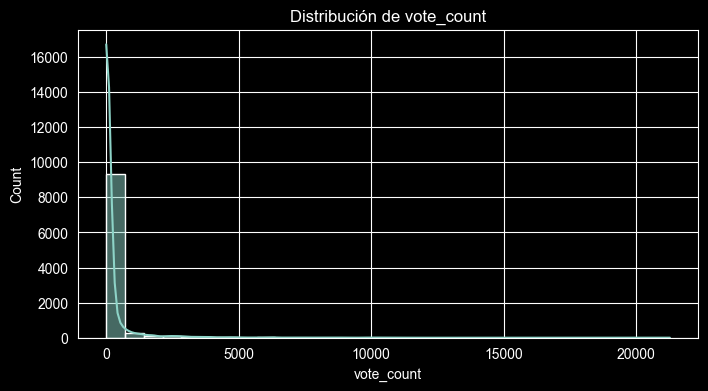

In [125]:


for col in num_cols[1:]:
    plt.figure(figsize=(8,4))
    sns.histplot(df_limpio[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.show()



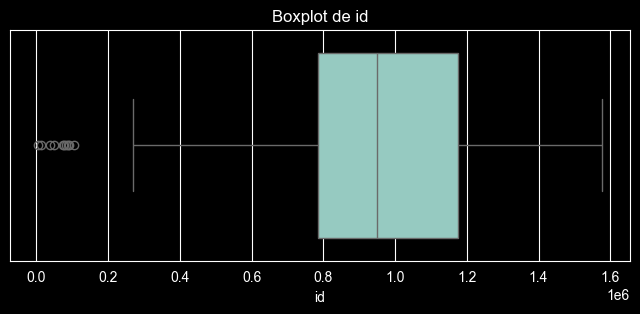

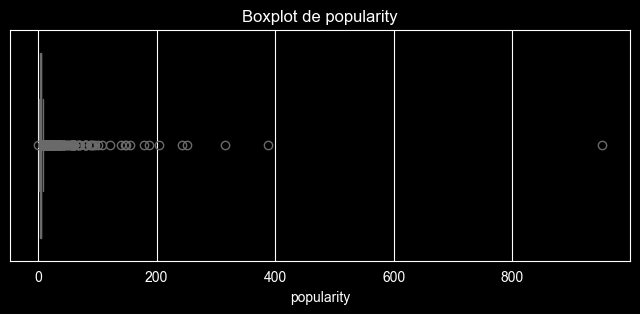

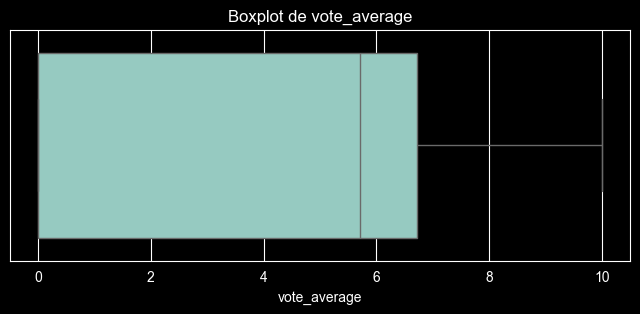

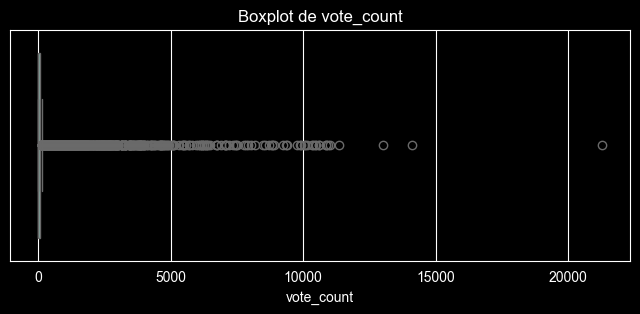

In [126]:

for col in num_cols[1:]:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df_limpio[col])
    plt.title(f"Boxplot de {col}")
    plt.show()


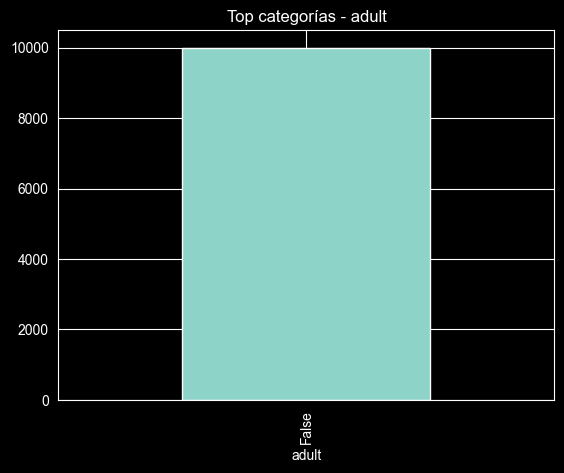

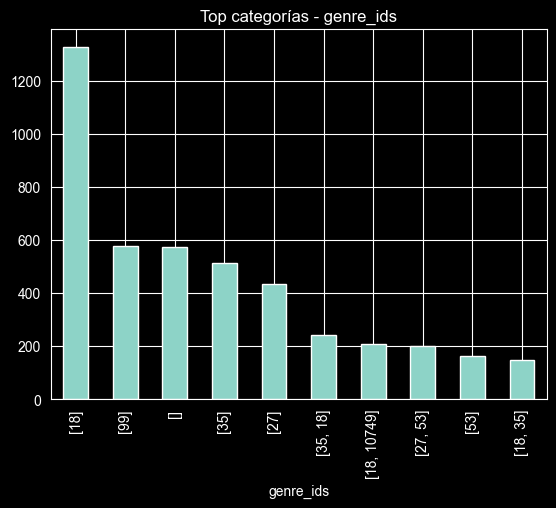

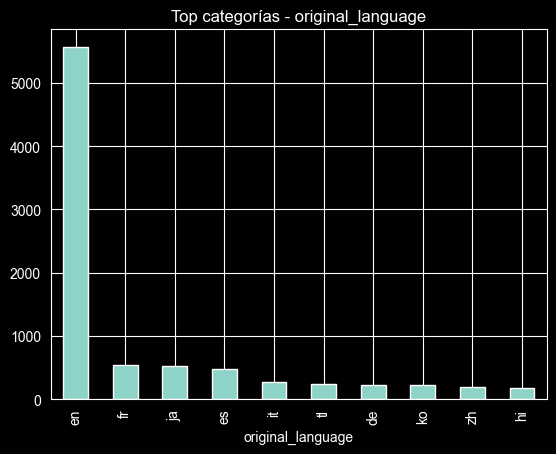

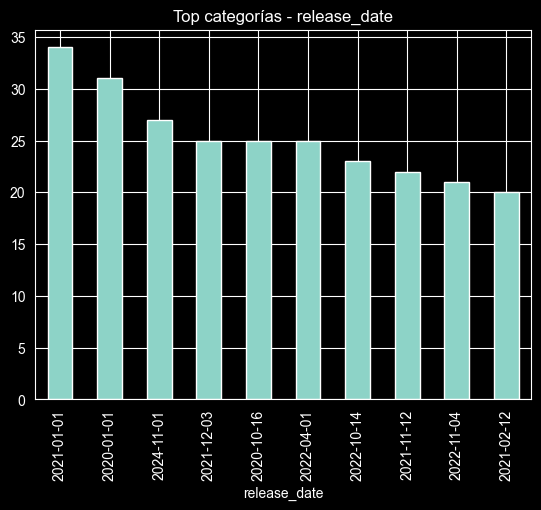

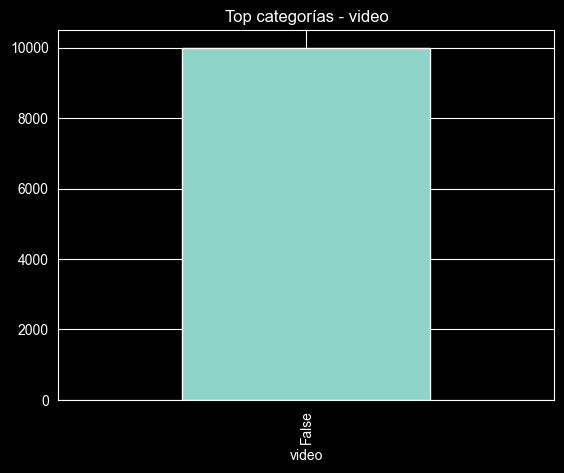

In [130]:

cat_cols_filtradas = [
    col for col in cat_cols
    if col not in ["title", "overview","original_title"]
]

for col in cat_cols_filtradas:
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top categorías - {col}")
    plt.show()



## Variable categoricas

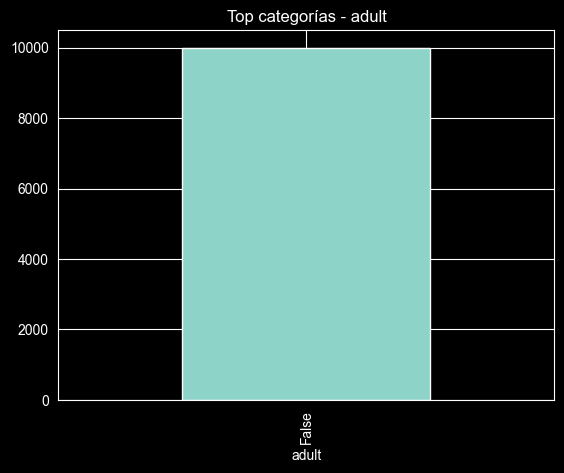

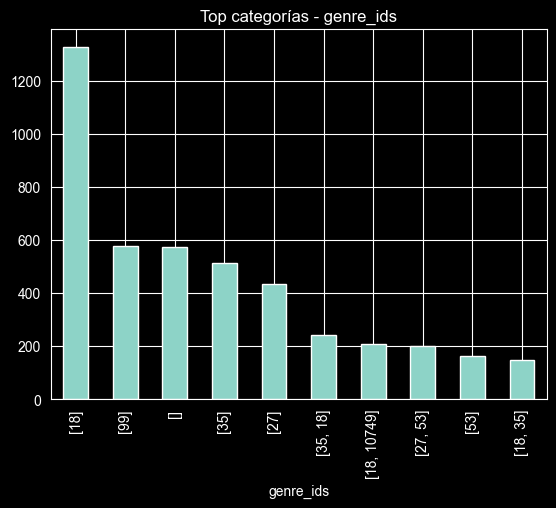

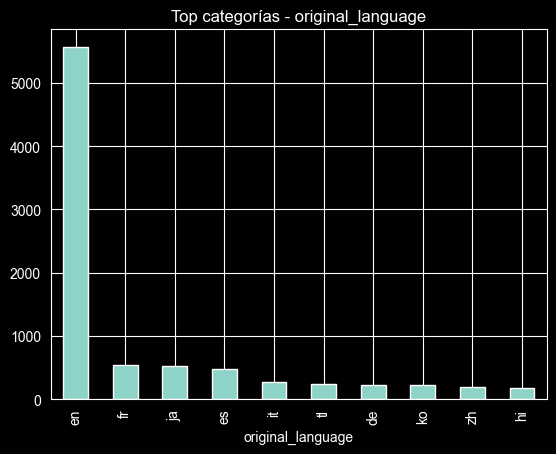

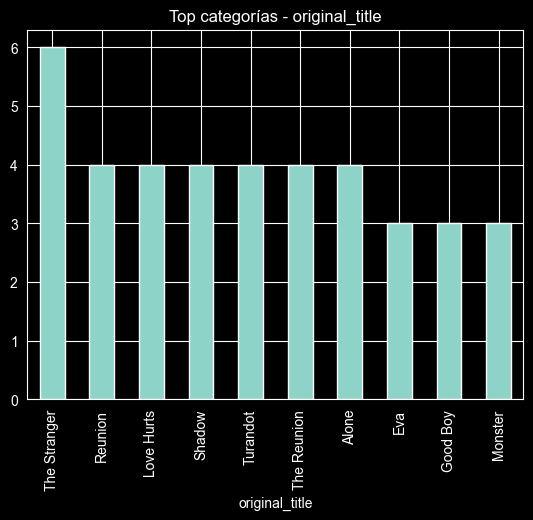

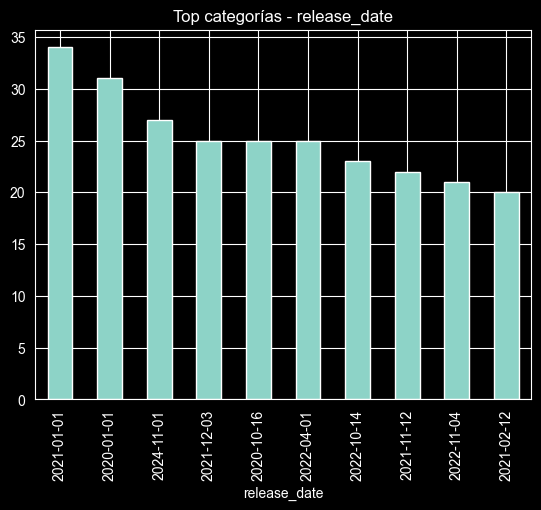

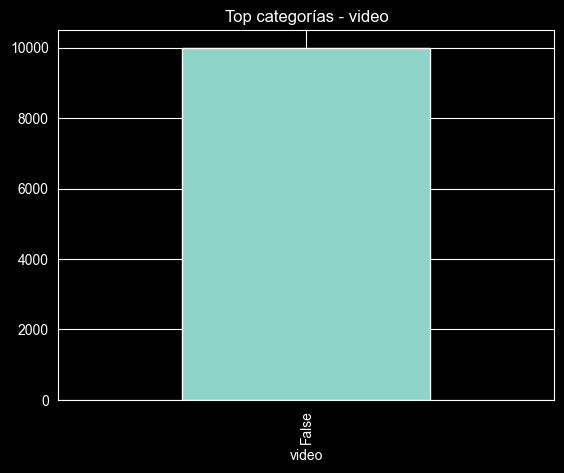

In [128]:

for col in cat_cols:
    if col in ["title", "overview"]:
        continue

    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Top categorías - {col}")
    plt.show()



## Pie chart (idioma)

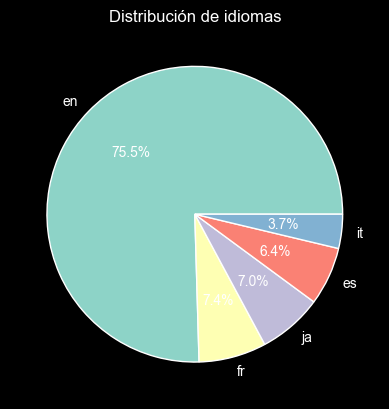

In [66]:

df_limpio["original_language"].value_counts().head(5).plot(
    kind="pie", autopct="%1.1f%%"
)
plt.title("Distribución de idiomas")
plt.ylabel("")
plt.show()


## Análisis bivariado

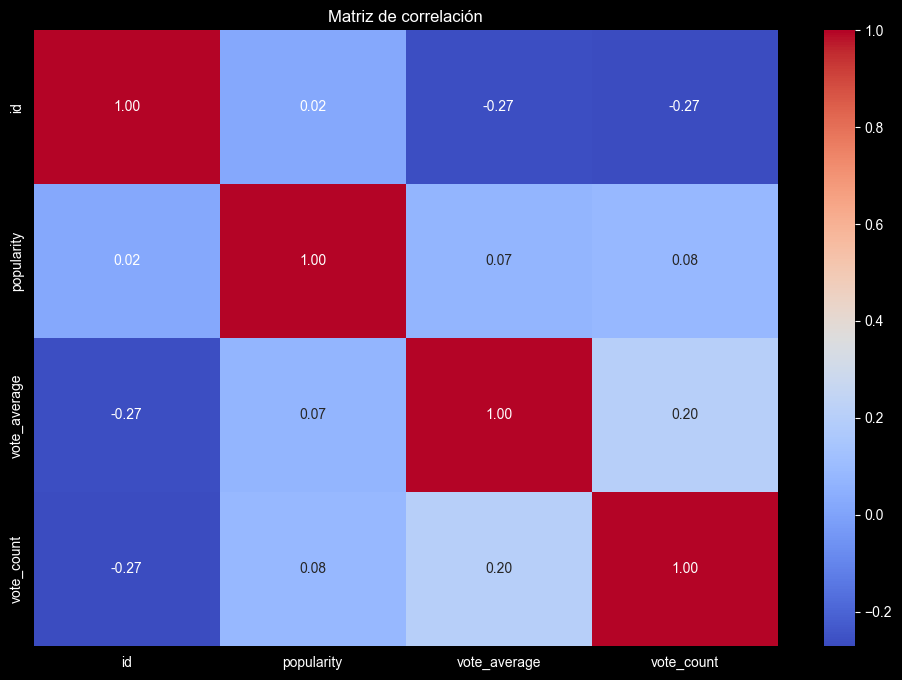

In [132]:
corr = df_limpio[num_cols[1:]].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

## Popularidad vs Promedio de votos

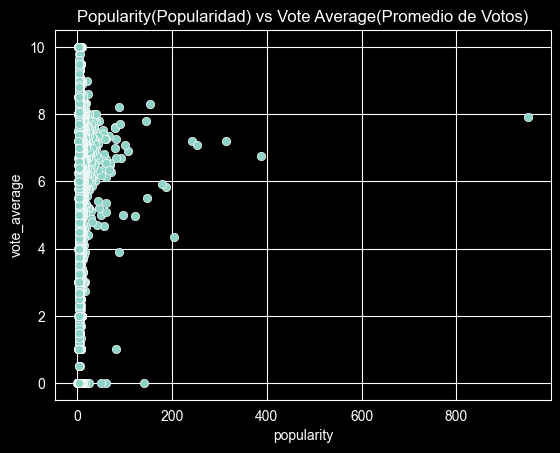

In [69]:
sns.scatterplot(
    data=df,
    x="popularity",
    y="vote_average"
)
plt.title("Popularity(Popularidad) vs Vote Average(Promedio de Votos)")
plt.show()


## PCA – Análisis de Componentes Principales

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_limpio[num_cols]
X_scaled = StandardScaler().fit_transform(X)

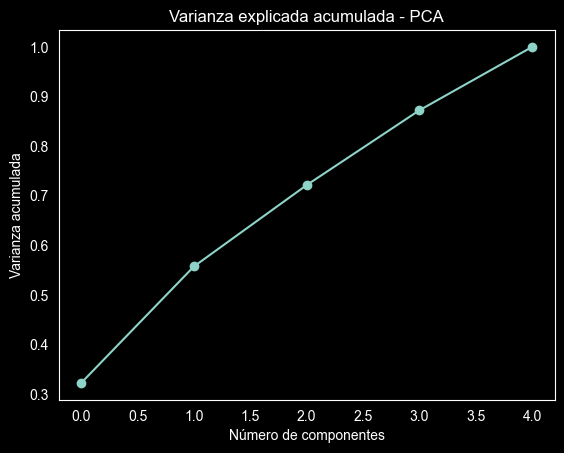

In [72]:

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza explicada acumulada - PCA")
plt.grid()
plt.show()


## PCA 2D (visualización)

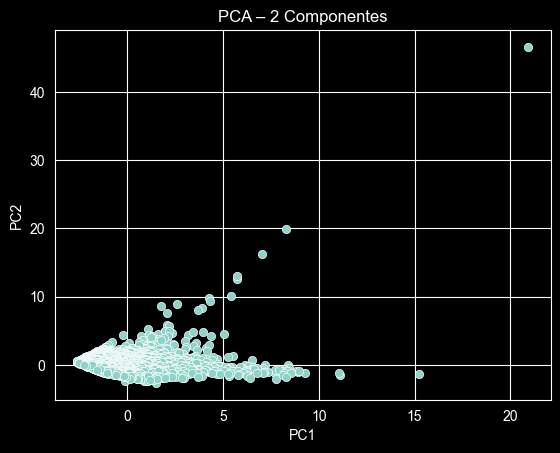

In [73]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])

sns.scatterplot(data=df_pca, x="PC1", y="PC2")
plt.title("PCA – 2 Componentes")
plt.show()

In [74]:

loadings = pd.DataFrame(
    pca.components_.T,
    index=num_cols,
    columns=[f"PC{i+1}" for i in range(len(num_cols))]
)

loadings[["PC1", "PC2"]]


,PC1,PC2
Unnamed: 0,-0.408995,-0.534451
id,-0.460477,0.502002
popularity,0.267040,0.635630
vote_average,0.495910,-0.227805
vote_count,0.550859,-0.080230


#### El primer componente principal (PC1) está fuertemente influenciado por el número de votos y la calificación promedio, representando un eje de popularidad consolidada y recepción del público.

#### El segundo componente principal (PC2) está dominado por la variable popularity, reflejando la visibilidad y tendencia actual de las películas más allá de su valoración histórica.

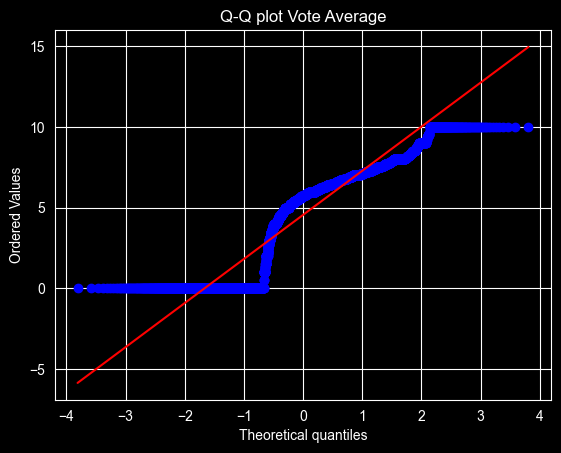

In [104]:

import scipy.stats as stats

stats.probplot(df["vote_average"], plot=plt)
plt.title("Q-Q plot Vote Average")
plt.show()


In [105]:

from scipy.stats import shapiro

stat, p = shapiro(df["vote_average"].sample(500, random_state=42))
stat, p


(np.float64(0.8455364068885485), np.float64(1.0870672912874363e-21))

In [108]:
import statsmodels.api as sm

X = df["vote_count"]
y = df["popularity"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             popularity   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     66.16
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           4.65e-16
Time:                        13:47:55   Log-Likelihood:                -39879.
No. Observations:                9999   AIC:                         7.976e+04
Df Residuals:                    9997   BIC:                         7.978e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5467      0.135     41.182      0.000       5.283       5.811
vote_count     0.0012      0.000      8.134      0.000       0.001       0.001
==============================================================================
Omnibus:                    30359.066   Durbin-Watson:                   0.644
Prob(Omnibus):                  0.000   Jarque-Bera (JB):       3470003218.874
Skew:                          44.953   Prob(JB):                         0.00
Kurtosis:                    2887.572   Cond. No.                         935.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""